# Mixed precision for VAE decoder

Test whether running the VAE decoder in bfloat16/float16 can reduce compute and memory
while maintaining acceptable accuracy for shear inference.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import equinox as eqx
from pathlib import Path
from functools import partial
import time

from pshear.utils import load_galaxy_autoencoder
from src.shearest.data_gen_utils import apply_shear, image_to_kimage, draw_NN_profile
from src.shearest.func_utils import complex_2_stack, stack_2_complex

print(f'JAX version: {jax.__version__}')
print(f'Default backend: {jax.default_backend()}')
print(f'Devices: {jax.devices()}')

JAX version: 0.6.2
Default backend: cpu
Devices: [CpuDevice(id=0)]


/Users/ec270266/anaconda3/envs/forwardmodel/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup

In [2]:
# Parameters
Npx = 128
pixel_scale_radio = 0.15
pixel_scale_vae = 0.03
latent_dim = 4
latent_mean = 0.75

# Load VAE
VAE_PATH = Path('/Users/ec270266/Documents/Phd/Argos/repos/probabilistic-shear/models/pretrained_benjamin')
ae = load_galaxy_autoencoder(VAE_PATH, epoch=920)

# UV setup
import argosim
import argosim.antenna_utils
import argosim.imaging_utils

fov_size = Npx * pixel_scale_radio / 3600
antenna = argosim.antenna_utils.random_antenna_arr(n_antenna=15, E_lim=40e3, N_lim=40e3, seed=123)
b_enu = argosim.antenna_utils.get_baselines(antenna)
track, _ = argosim.antenna_utils.uv_track_multiband(
    b_ENU=b_enu, track_time=8, n_times=96, f=1.4e9, df=1e8, n_freqs=1
)
mask, _ = argosim.imaging_utils.grid_uv_samples(
    track, sky_uv_shape=(Npx, Npx), fov_size=(fov_size, fov_size)
)
uv_pos = np.where(np.abs(mask) > 0.)
print(f'UV samples: {len(uv_pos[0])}')

UV samples: 545


/Users/ec270266/anaconda3/envs/forwardmodel/lib/python3.11/site-packages/argosim/imaging_utils.py:122: UserWarning: Explicitly requested dtype <class 'jax.numpy.complex128'> requested in zeros is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  uv_mask = jnp.zeros(sky_uv_shape, dtype=jnp.complex128)


In [3]:
# Test data
key = jax.random.PRNGKey(42)
z = jax.random.normal(key, (latent_dim, latent_dim)) + latent_mean
flux = 0.1
g1, g2 = 0.05, -0.05

## Inspect model parameter dtypes and sizes

In [4]:
# Count parameters and memory by dtype
leaves = jax.tree.leaves(ae)
dtype_counts = {}
dtype_bytes = {}
total_params = 0
for leaf in leaves:
    if hasattr(leaf, 'dtype') and hasattr(leaf, 'size'):
        d = str(leaf.dtype)
        dtype_counts[d] = dtype_counts.get(d, 0) + leaf.size
        dtype_bytes[d] = dtype_bytes.get(d, 0) + leaf.nbytes
        total_params += leaf.size

print(f'Total parameters: {total_params:,}')
print(f'\nBy dtype:')
for d in sorted(dtype_counts.keys()):
    print(f'  {d}: {dtype_counts[d]:>10,} params, {dtype_bytes[d]/1024/1024:>6.2f} MB')

Total parameters: 33,116,226

By dtype:
  float32: 33,116,226 params, 126.33 MB


## Convert model to lower precision

In [5]:
def model_to_dtype(model, dtype):
    """Convert all float32 array leaves to the target dtype."""
    def convert(x):
        if isinstance(x, jnp.ndarray) and jnp.issubdtype(x.dtype, jnp.floating):
            return x.astype(dtype)
        return x
    return jax.tree.map(convert, model)

ae_bf16 = model_to_dtype(ae, jnp.bfloat16)
ae_f16 = model_to_dtype(ae, jnp.float16)

# Verify conversion
for name, model in [('float32', ae), ('bfloat16', ae_bf16), ('float16', ae_f16)]:
    leaves = jax.tree.leaves(model)
    float_leaves = [l for l in leaves if hasattr(l, 'dtype') and jnp.issubdtype(l.dtype, jnp.floating)]
    total_bytes = sum(l.nbytes for l in float_leaves)
    dtypes = set(str(l.dtype) for l in float_leaves)
    print(f'{name:>8s}: dtypes={dtypes}, total={total_bytes/1024/1024:.2f} MB')

 float32: dtypes={'float32'}, total=126.33 MB
bfloat16: dtypes={'bfloat16'}, total=63.16 MB
 float16: dtypes={'float16'}, total=63.16 MB


## Compare decoder outputs

In [6]:
# JIT-compile decode for each precision
decode_f32 = eqx.filter_jit(lambda z, key: ae.decode(z, key=key))
decode_bf16 = eqx.filter_jit(lambda z, key: ae_bf16.decode(z, key=key))
decode_f16 = eqx.filter_jit(lambda z, key: ae_f16.decode(z, key=key))

# Decode
y_f32 = decode_f32(z[None,:,:], key=None)[0]
y_bf16 = decode_bf16(z[None,:,:].astype(jnp.bfloat16), key=None)[0]
y_f16 = decode_f16(z[None,:,:].astype(jnp.float16), key=None)[0]

# Cast back to float32 for comparison
y_bf16_f32 = y_bf16.astype(jnp.float32)
y_f16_f32 = y_f16.astype(jnp.float32)

print(f'Output dtypes: f32={y_f32.dtype}, bf16={y_bf16.dtype}, f16={y_f16.dtype}')
print(f'Output ranges:')
print(f'  f32:  [{y_f32.min():.4f}, {y_f32.max():.4f}]')
print(f'  bf16: [{y_bf16_f32.min():.4f}, {y_bf16_f32.max():.4f}]')
print(f'  f16:  [{y_f16_f32.min():.4f}, {y_f16_f32.max():.4f}]')

# Errors
for name, y_low in [('bfloat16', y_bf16_f32), ('float16', y_f16_f32)]:
    ae_val = jnp.abs(y_f32 - y_low)
    re_val = ae_val / (jnp.abs(y_f32) + 1e-10)
    print(f'\n{name} vs float32:')
    print(f'  abs error: max={jnp.max(ae_val):.2e}, mean={jnp.mean(ae_val):.2e}')
    print(f'  rel error: max={jnp.max(re_val):.2e}, median={jnp.median(re_val):.2e}')

Output dtypes: f32=float32, bf16=bfloat16, f16=float16
Output ranges:
  f32:  [0.0000, 0.1034]
  bf16: [0.0000, 0.1035]
  f16:  [0.0000, 0.1036]

bfloat16 vs float32:
  abs error: max=1.12e-03, mean=4.29e-06
  rel error: max=1.57e-01, median=1.94e-02

float16 vs float32:
  abs error: max=2.03e-04, mean=7.60e-07
  rel error: max=1.01e+00, median=4.89e-01


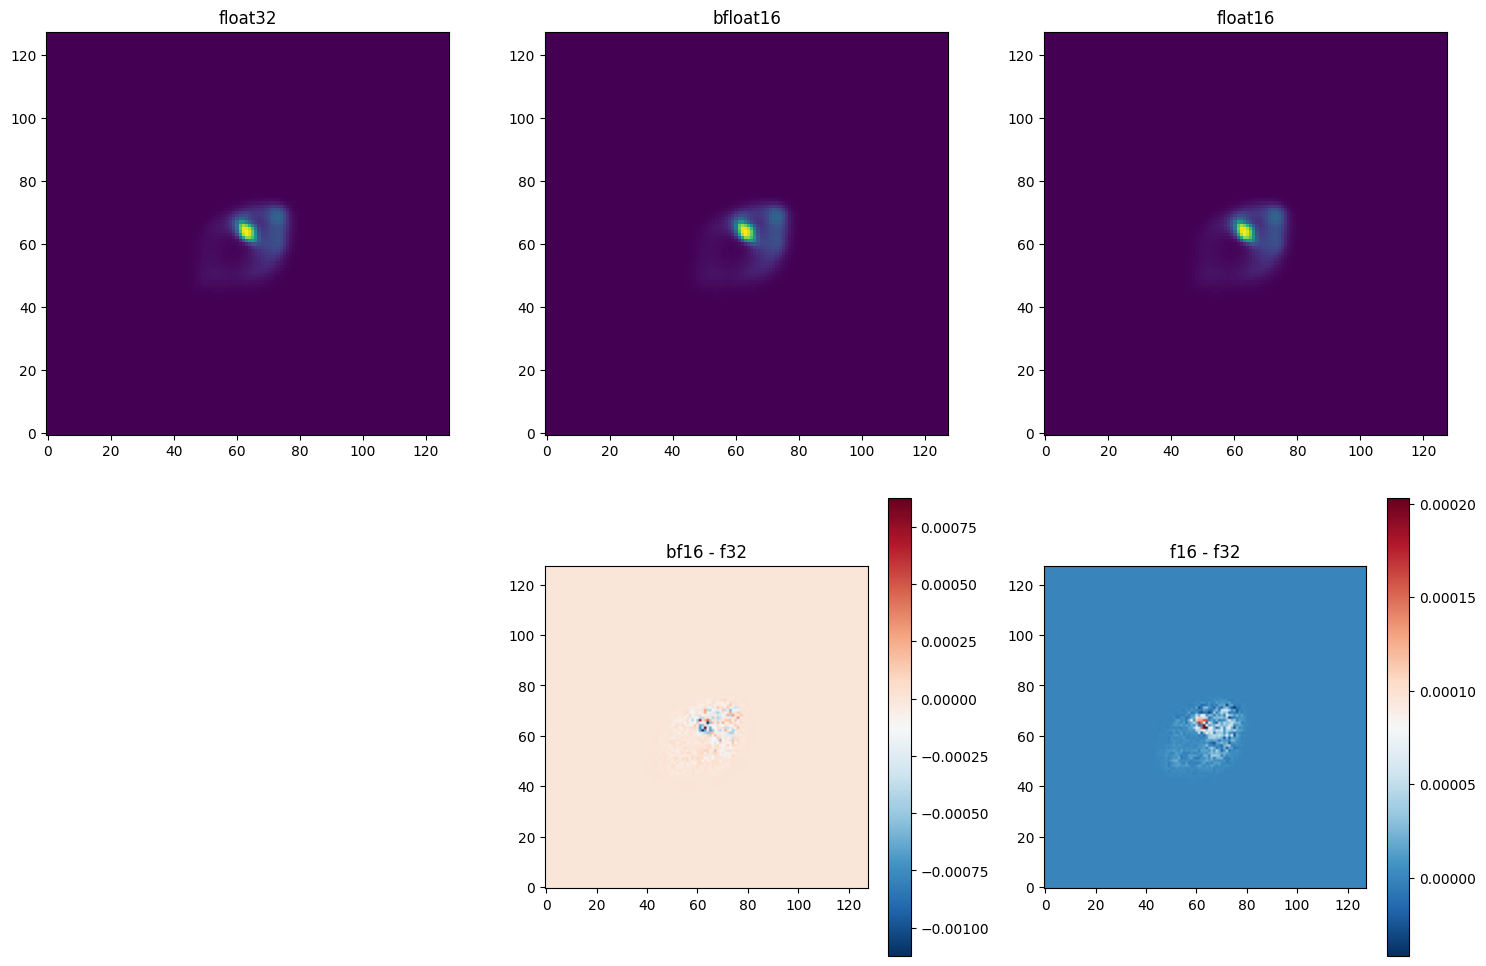

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
vmax = float(jnp.max(y_f32))

for i, (name, img) in enumerate([('float32', y_f32), ('bfloat16', y_bf16_f32), ('float16', y_f16_f32)]):
    axes[0, i].imshow(img, origin='lower', vmax=vmax)
    axes[0, i].set_title(f'{name}')

# Difference maps
for i, (name, img) in enumerate([('bf16 - f32', y_bf16_f32 - y_f32), ('f16 - f32', y_f16_f32 - y_f32)]):
    im = axes[1, i+1].imshow(img, origin='lower', cmap='RdBu_r')
    axes[1, i+1].set_title(name)
    plt.colorbar(im, ax=axes[1, i+1])

axes[1, 0].axis('off')
plt.tight_layout()
plt.show()

## Compare full pipeline visibilities

In [8]:
# Full draw_NN_profile with each precision
# Note: shear + FFT stay in float32; only the decoder changes precision

def draw_mixed_precision(z, flux, g1, g2, key, uv_pos, Npx, pixel_scale_radio,
                         pixel_scale_vae, decode_fn):
    """draw_NN_profile but with a configurable decode function."""
    y = decode_fn(z[None,:,:], key=None)[0]
    # Cast back to float32 for the rest of the pipeline
    y = y.astype(jnp.float32)
    y = y * flux / (jnp.sum(y) * pixel_scale_vae**2)
    y_sheared = apply_shear(y, g1, g2)
    y_kimage = image_to_kimage(y_sheared, pixel_scale_vae, Npx, pixel_scale_radio)
    vis = y_kimage[uv_pos]
    return complex_2_stack(vis)

draw_f32 = jax.jit(partial(draw_mixed_precision,
    uv_pos=uv_pos, Npx=Npx, pixel_scale_radio=pixel_scale_radio,
    pixel_scale_vae=pixel_scale_vae, decode_fn=decode_f32))

draw_bf16 = jax.jit(partial(draw_mixed_precision,
    uv_pos=uv_pos, Npx=Npx, pixel_scale_radio=pixel_scale_radio,
    pixel_scale_vae=pixel_scale_vae, decode_fn=decode_bf16))

draw_f16 = jax.jit(partial(draw_mixed_precision,
    uv_pos=uv_pos, Npx=Npx, pixel_scale_radio=pixel_scale_radio,
    pixel_scale_vae=pixel_scale_vae, decode_fn=decode_f16))

# Note: bf16/f16 decoders expect lower-precision input
vis_f32 = draw_f32(z, flux, g1, g2, None)
vis_bf16 = draw_bf16(z.astype(jnp.bfloat16), flux, g1, g2, None)
vis_f16 = draw_f16(z.astype(jnp.float16), flux, g1, g2, None)

for name, vis_low in [('bfloat16', vis_bf16), ('float16', vis_f16)]:
    v_ref = vis_f32[0] + 1j * vis_f32[1]
    v_low = vis_low[0] + 1j * vis_low[1]
    ae_val = jnp.abs(v_ref - v_low)
    re_val = ae_val / (jnp.abs(v_ref) + 1e-10)
    print(f'{name} pipeline vs float32:')
    print(f'  abs error: max={jnp.max(ae_val):.2e}, mean={jnp.mean(ae_val):.2e}')
    print(f'  rel error: max={jnp.max(re_val):.2e}, median={jnp.median(re_val):.2e}')
    print()

bfloat16 pipeline vs float32:
  abs error: max=5.56e-05, mean=3.12e-05
  rel error: max=8.17e-04, median=3.86e-04

float16 pipeline vs float32:
  abs error: max=1.30e-05, mean=7.20e-06
  rel error: max=1.78e-04, median=8.50e-05



## Timing: single galaxy forward pass

In [9]:
# Warm up all
_ = draw_f32(z, flux, g1, g2, None).block_until_ready()
_ = draw_bf16(z.astype(jnp.bfloat16), flux, g1, g2, None).block_until_ready()
_ = draw_f16(z.astype(jnp.float16), flux, g1, g2, None).block_until_ready()

N_repeats = 100
results = {}

for name, draw_fn, z_in in [
    ('float32', draw_f32, z),
    ('bfloat16', draw_bf16, z.astype(jnp.bfloat16)),
    ('float16', draw_f16, z.astype(jnp.float16)),
]:
    t0 = time.time()
    for _ in range(N_repeats):
        _ = draw_fn(z_in, flux, g1, g2, None).block_until_ready()
    t = (time.time() - t0) / N_repeats
    results[name] = t
    print(f'{name:>8s}: {t*1000:.2f} ms/call')

print(f'\nbf16 speedup: {results["float32"]/results["bfloat16"]:.2f}x')
print(f'f16 speedup:  {results["float32"]/results["float16"]:.2f}x')

 float32: 21.09 ms/call
bfloat16: 26.37 ms/call
 float16: 21.15 ms/call

bf16 speedup: 0.80x
f16 speedup:  1.00x


## Timing: single galaxy gradient

In [10]:
def make_loss(draw_fn):
    def loss(z, flux, g1, g2, key):
        vis = draw_fn(z, flux, g1, g2, key)
        return jnp.sum(vis**2)
    return loss

grad_f32 = jax.jit(jax.grad(make_loss(draw_f32), argnums=(0, 1, 2, 3)))
grad_bf16 = jax.jit(jax.grad(make_loss(draw_bf16), argnums=(0, 1, 2, 3)))
grad_f16 = jax.jit(jax.grad(make_loss(draw_f16), argnums=(0, 1, 2, 3)))

# Warm up
for gf, z_in in [(grad_f32, z), (grad_bf16, z.astype(jnp.bfloat16)), (grad_f16, z.astype(jnp.float16))]:
    _ = gf(z_in, flux, g1, g2, None)
    _ = [x.block_until_ready() for x in _]

N_repeats_grad = 50
grad_results = {}

for name, gf, z_in in [
    ('float32', grad_f32, z),
    ('bfloat16', grad_bf16, z.astype(jnp.bfloat16)),
    ('float16', grad_f16, z.astype(jnp.float16)),
]:
    t0 = time.time()
    for _ in range(N_repeats_grad):
        grads = gf(z_in, flux, g1, g2, None)
        _ = [x.block_until_ready() for x in grads]
    t = (time.time() - t0) / N_repeats_grad
    grad_results[name] = t
    print(f'{name:>8s}: {t*1000:.2f} ms/call')

print(f'\nbf16 speedup: {grad_results["float32"]/grad_results["bfloat16"]:.2f}x')
print(f'f16 speedup:  {grad_results["float32"]/grad_results["float16"]:.2f}x')

 float32: 48.87 ms/call
bfloat16: 82.79 ms/call
 float16: 48.66 ms/call

bf16 speedup: 0.59x
f16 speedup:  1.00x


## Timing: vmapped gradient over 25 galaxies

In [11]:
Ngal_test = 25

z_batch = jax.random.normal(jax.random.PRNGKey(0), (Ngal_test, latent_dim, latent_dim)) + latent_mean
flux_batch = jnp.ones(Ngal_test) * 0.1
g1_batch = jnp.ones(Ngal_test) * g1
g2_batch = jnp.ones(Ngal_test) * g2
keys_batch = jnp.zeros((Ngal_test, 2), dtype=jnp.uint32)

def make_vmap_grad(decode_fn):
    draw = partial(draw_mixed_precision,
        uv_pos=uv_pos, Npx=Npx, pixel_scale_radio=pixel_scale_radio,
        pixel_scale_vae=pixel_scale_vae, decode_fn=decode_fn)
    vmap_draw = jax.jit(jax.vmap(draw))
    def loss(z_b, flux_b, g1_b, g2_b, keys_b):
        vis = vmap_draw(z_b, flux_b, g1_b, g2_b, keys_b)
        return jnp.sum(vis**2)
    return jax.jit(jax.grad(loss, argnums=(0, 1, 2, 3)))

vgrad_f32 = make_vmap_grad(decode_f32)
vgrad_bf16 = make_vmap_grad(decode_bf16)
vgrad_f16 = make_vmap_grad(decode_f16)

# Warm up
for vgf, z_in in [
    (vgrad_f32, z_batch),
    (vgrad_bf16, z_batch.astype(jnp.bfloat16)),
    (vgrad_f16, z_batch.astype(jnp.float16)),
]:
    _ = vgf(z_in, flux_batch, g1_batch, g2_batch, keys_batch)
    _ = [x.block_until_ready() for x in _]

N_repeats_vmap = 20
vgrad_results = {}

for name, vgf, z_in in [
    ('float32', vgrad_f32, z_batch),
    ('bfloat16', vgrad_bf16, z_batch.astype(jnp.bfloat16)),
    ('float16', vgrad_f16, z_batch.astype(jnp.float16)),
]:
    t0 = time.time()
    for _ in range(N_repeats_vmap):
        grads = vgf(z_in, flux_batch, g1_batch, g2_batch, keys_batch)
        _ = [x.block_until_ready() for x in grads]
    t = (time.time() - t0) / N_repeats_vmap
    vgrad_results[name] = t
    print(f'{name:>8s}: {t*1000:.1f} ms')

print(f'\nbf16 speedup: {vgrad_results["float32"]/vgrad_results["bfloat16"]:.2f}x')
print(f'f16 speedup:  {vgrad_results["float32"]/vgrad_results["float16"]:.2f}x')

 float32: 764.5 ms
bfloat16: 1829.5 ms
 float16: 781.5 ms

bf16 speedup: 0.42x
f16 speedup:  0.98x


## Gradient accuracy check

Verify that lower precision doesn't corrupt gradients w.r.t. z, flux, g1, g2.

In [12]:
grads_ref = grad_f32(z, flux, g1, g2, None)
grads_bf16_val = grad_bf16(z.astype(jnp.bfloat16), flux, g1, g2, None)
grads_f16_val = grad_f16(z.astype(jnp.float16), flux, g1, g2, None)

labels = ['z', 'flux', 'g1', 'g2']

for prec_name, grads_low in [('bfloat16', grads_bf16_val), ('float16', grads_f16_val)]:
    print(f'\n{prec_name} vs float32 gradients:')
    print(f'{"param":>6s} | {"max_abs_err":>12s} {"max_rel_err":>12s}')
    print('-' * 40)
    for label, gc, gk in zip(labels, grads_ref, grads_low):
        gc_f32 = gc.astype(jnp.float32)
        gk_f32 = gk.astype(jnp.float32)
        ae_val = jnp.max(jnp.abs(gc_f32 - gk_f32))
        re_val = jnp.max(jnp.abs(gc_f32 - gk_f32) / (jnp.abs(gc_f32) + 1e-10))
        print(f'{label:>6s} | {ae_val:>12.2e} {re_val:>12.2e}')


bfloat16 vs float32 gradients:
 param |  max_abs_err  max_rel_err
----------------------------------------
     z |     3.19e-03     1.41e-02
  flux |     3.38e-02     4.25e-04
    g1 |     4.10e-03     7.31e-03
    g2 |     4.58e-03     2.21e-02

float16 vs float32 gradients:
 param |  max_abs_err  max_rel_err
----------------------------------------
     z |     4.73e-04     1.13e-02
  flux |     2.03e-03     2.55e-05
    g1 |     4.84e-04     8.63e-04
    g2 |     7.87e-04     3.80e-03


## Alternative: float32 compute with `jax.default_matmul_precision`

Instead of converting weights, we can lower the matmul precision.
This keeps weights in float32 but uses lower-precision tensor cores for matrix multiplies.

In [13]:
# Test with different matmul precision settings
# 'highest' = float32, 'high' = tf32/3xbf16, 'default' = bf16 on GPU

decode_f32_fn = eqx.filter_jit(lambda z, key: ae.decode(z, key=key))

for precision in ['highest', 'high', 'default']:
    with jax.default_matmul_precision(precision):
        draw_prec = jax.jit(partial(draw_mixed_precision,
            uv_pos=uv_pos, Npx=Npx, pixel_scale_radio=pixel_scale_radio,
            pixel_scale_vae=pixel_scale_vae,
            decode_fn=eqx.filter_jit(lambda z, key: ae.decode(z, key=key))))
        
        vis = draw_prec(z, flux, g1, g2, None).block_until_ready()
        
        # Compare to reference
        v_ref = vis_f32[0] + 1j * vis_f32[1]
        v_prec = vis[0] + 1j * vis[1]
        re = jnp.abs(v_ref - v_prec) / (jnp.abs(v_ref) + 1e-10)
        
        # Time it
        _ = draw_prec(z, flux, g1, g2, None).block_until_ready()
        t0 = time.time()
        for _ in range(N_repeats):
            _ = draw_prec(z, flux, g1, g2, None).block_until_ready()
        t = (time.time() - t0) / N_repeats
        
        print(f'{precision:>8s}: {t*1000:.2f} ms, median_rel_err={jnp.median(re):.2e}')

 highest: 20.79 ms, median_rel_err=0.00e+00
    high: 20.28 ms, median_rel_err=0.00e+00
 default: 20.46 ms, median_rel_err=0.00e+00


## Summary

In [14]:
print('=' * 60)
print('SUMMARY')
print('=' * 60)
print(f'\nForward pass (single galaxy):')
for name in ['float32', 'bfloat16', 'float16']:
    speedup = results['float32'] / results[name]
    print(f'  {name:>8s}: {results[name]*1000:>6.2f} ms  ({speedup:.2f}x)')

print(f'\nGradient (single galaxy):')
for name in ['float32', 'bfloat16', 'float16']:
    speedup = grad_results['float32'] / grad_results[name]
    print(f'  {name:>8s}: {grad_results[name]*1000:>6.2f} ms  ({speedup:.2f}x)')

print(f'\nVmapped gradient ({Ngal_test} galaxies):')
for name in ['float32', 'bfloat16', 'float16']:
    speedup = vgrad_results['float32'] / vgrad_results[name]
    print(f'  {name:>8s}: {vgrad_results[name]*1000:>6.1f} ms  ({speedup:.2f}x)')

print(f'\nNote: On CPU, lower precision may not give speedups.')
print(f'GPU (V100) has native bfloat16/float16 tensor cores that')
print(f'should give ~2x speedup on matmul-heavy operations.')

SUMMARY

Forward pass (single galaxy):
   float32:  21.09 ms  (1.00x)
  bfloat16:  26.37 ms  (0.80x)
   float16:  21.15 ms  (1.00x)

Gradient (single galaxy):
   float32:  48.87 ms  (1.00x)
  bfloat16:  82.79 ms  (0.59x)
   float16:  48.66 ms  (1.00x)

Vmapped gradient (25 galaxies):
   float32:  764.5 ms  (1.00x)
  bfloat16: 1829.5 ms  (0.42x)
   float16:  781.5 ms  (0.98x)

Note: On CPU, lower precision may not give speedups.
GPU (V100) has native bfloat16/float16 tensor cores that
should give ~2x speedup on matmul-heavy operations.
